# Addition Technologies Pvt Ltd – Self-Serve Kiosk Sales Dashboards

**Analysis Period:** October 2025 – December 2025  
**Clients:** Veena Stores | Rameshwaram Cafe | Asha Sweets | Bigbyte  
**Location:** Bangalore

## Dashboards
| # | Title |
|---|-------|
| Dashboard 1 | Kiosk Sales Analytics – Food Item Revenue of All Clients/Restaurants (Oct–Dec 2025) |
| Dashboard 2 | Sales Comparison of All 4 Clients (Oct–Dec 2025) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#F5F7FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DDDDDD',
    'axes.grid':        True,
    'grid.color':       '#EEEEEE',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11
})

# Brand colour palette – ordered by target sales rank
REST_ORDER  = ['Veena Stores', 'Rameshwaram Cafe', 'Asha Sweets', 'Bigbyte']
REST_COLORS = {
    'Veena Stores':     '#1F6FEB',   # blue  – #1 (target leader)
    'Rameshwaram Cafe': '#2EA043',   # green – #2
    'Asha Sweets':      '#D2A8FF',   # purple– #3
    'Bigbyte':          '#F78166',   # orange– #4
}
print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv('Self_Serve_Kiosks_Sales_Data.csv', parse_dates=['Date','Order_DateTime'])
df['Month'] = pd.Categorical(
    df['Month'],
    categories=['October 2025','November 2025','December 2025'],
    ordered=True
)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Date range: {df.Date.min().date()} → {df.Date.max().date()}')
print('Null values:', df.isnull().sum().sum())
print('\nNet Sales by Restaurant (target rank: Veena > Rameshwaram > Asha > Bigbyte):')
print(df.groupby('Restaurant')['Net_Sales'].sum()
        .reindex(REST_ORDER).map('₹{:,.0f}'.format))
df.head(3)

Rows: 136,804  |  Columns: 21
Date range: 2025-10-01 → 2025-12-31
Null values: 0

Net Sales by Restaurant (target rank: Veena > Rameshwaram > Asha > Bigbyte):
Restaurant
Veena Stores        ₹3,612,578
Rameshwaram Cafe    ₹3,179,052
Asha Sweets         ₹2,425,734
Bigbyte             ₹1,571,108
Name: Net_Sales, dtype: str


,Transaction_ID,Date,Month,Month_Num,Year,Day_of_Week,Order_DateTime,Restaurant,Kiosk_ID,Customer_ID,...,Category,Unit_Price,Quantity,Total_Sales,Discount,Net_Sales,Payment_Mode,City,Is_Weekend,Is_Festival_Day
0,TXN-000001,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 20:56:00,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0001,...,South Indian,75,1,75,0.00,75.00,Card,Bangalore,False,False
1,TXN-000002,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 20:56:00,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0001,...,South Indian,40,1,40,0.00,40.00,Card,Bangalore,False,False
2,TXN-000003,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 08:11:00,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0002,...,South Indian,75,1,75,3.75,71.25,UPI,Bangalore,False,False


---
# 📊 Dashboard 1
## Kiosk Sales Analytics – Food Item Revenue of All Clients/Restaurants
### October – December 2025

> One combined view showing food-item revenue across **all 4 restaurants** with KPIs.


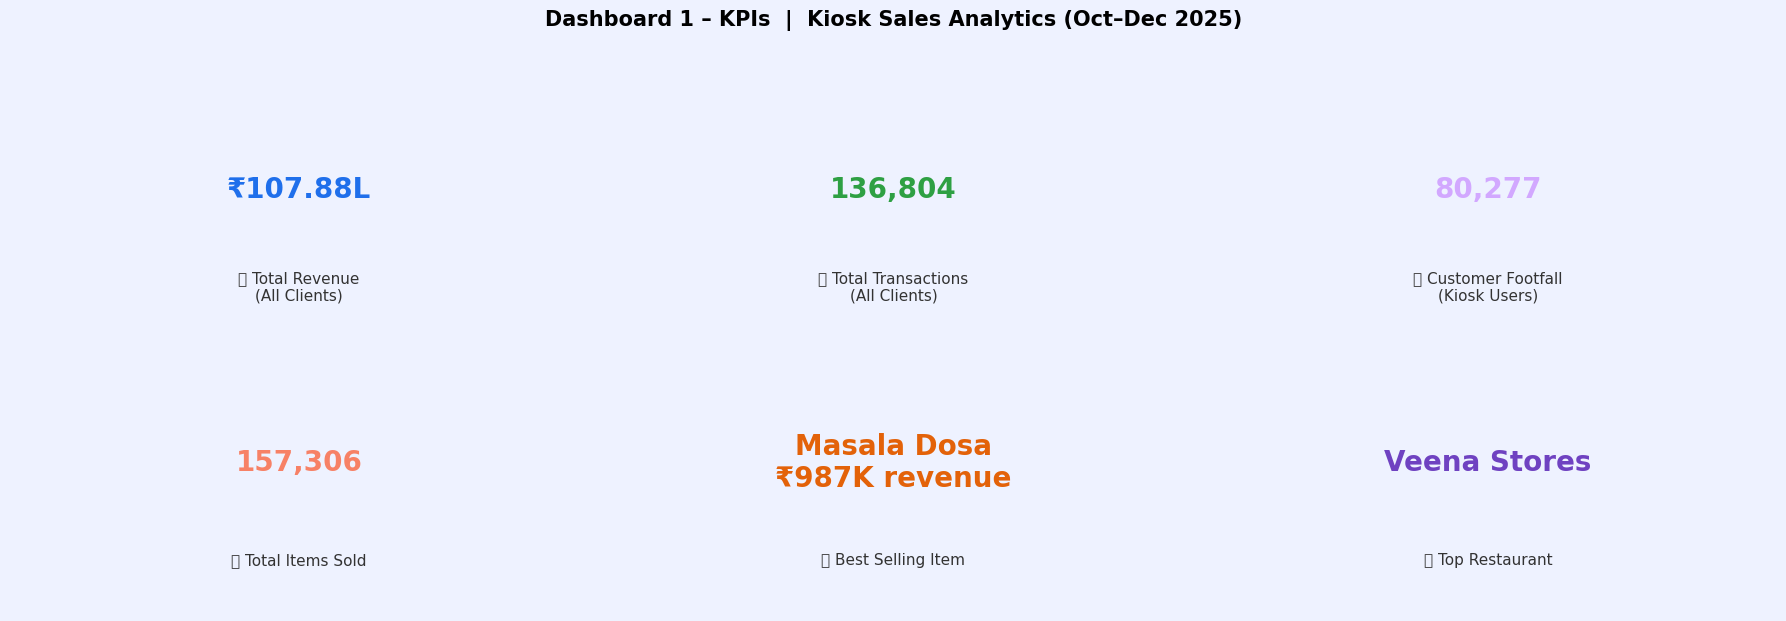

D1 KPI cards saved.


In [3]:
# ─── KPI calculations ───────────────────────────────────────────────────
total_revenue   = df['Net_Sales'].sum()
total_items     = df['Quantity'].sum()
total_txn       = len(df)
unique_footfall = df['Customer_ID'].nunique()
top_item        = df.groupby('Food_Item')['Net_Sales'].sum().idxmax()
top_item_rev    = df.groupby('Food_Item')['Net_Sales'].sum().max()
top_rest        = df.groupby('Restaurant')['Net_Sales'].sum().idxmax()
top_cat         = df.groupby('Category')['Net_Sales'].sum().idxmax()

kpis = [
    ('💰 Total Revenue\n(All Clients)',       f'₹{total_revenue/1e5:.2f}L'),
    ('🧾 Total Transactions\n(All Clients)',   f'{total_txn:,}'),
    ('👣 Customer Footfall\n(Kiosk Users)',    f'{unique_footfall:,}'),
    ('📦 Total Items Sold',                    f'{total_items:,}'),
    ('🥇 Best Selling Item',                   f'{top_item}\n₹{top_item_rev/1e3:.0f}K revenue'),
    ('🏆 Top Restaurant',                      top_rest),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
fig.suptitle(
    'Dashboard 1 – KPIs  |  Kiosk Sales Analytics (Oct–Dec 2025)',
    fontsize=15, fontweight='bold', y=1.03
)
fig.patch.set_facecolor('#EEF2FF')
kpi_colors = ['#1F6FEB','#2EA043','#D2A8FF','#F78166','#E36209','#6F42C1']
for ax, (label, val), clr in zip(axes.flat, kpis, kpi_colors):
    ax.set_facecolor(clr + '22')
    ax.text(0.5, 0.58, val,   ha='center', va='center', fontsize=20,
            fontweight='bold', color=clr, transform=ax.transAxes, wrap=True)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=11,
            color='#333', transform=ax.transAxes)
    ax.axis('off')
plt.tight_layout()
plt.savefig('d1_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('D1 KPI cards saved.')

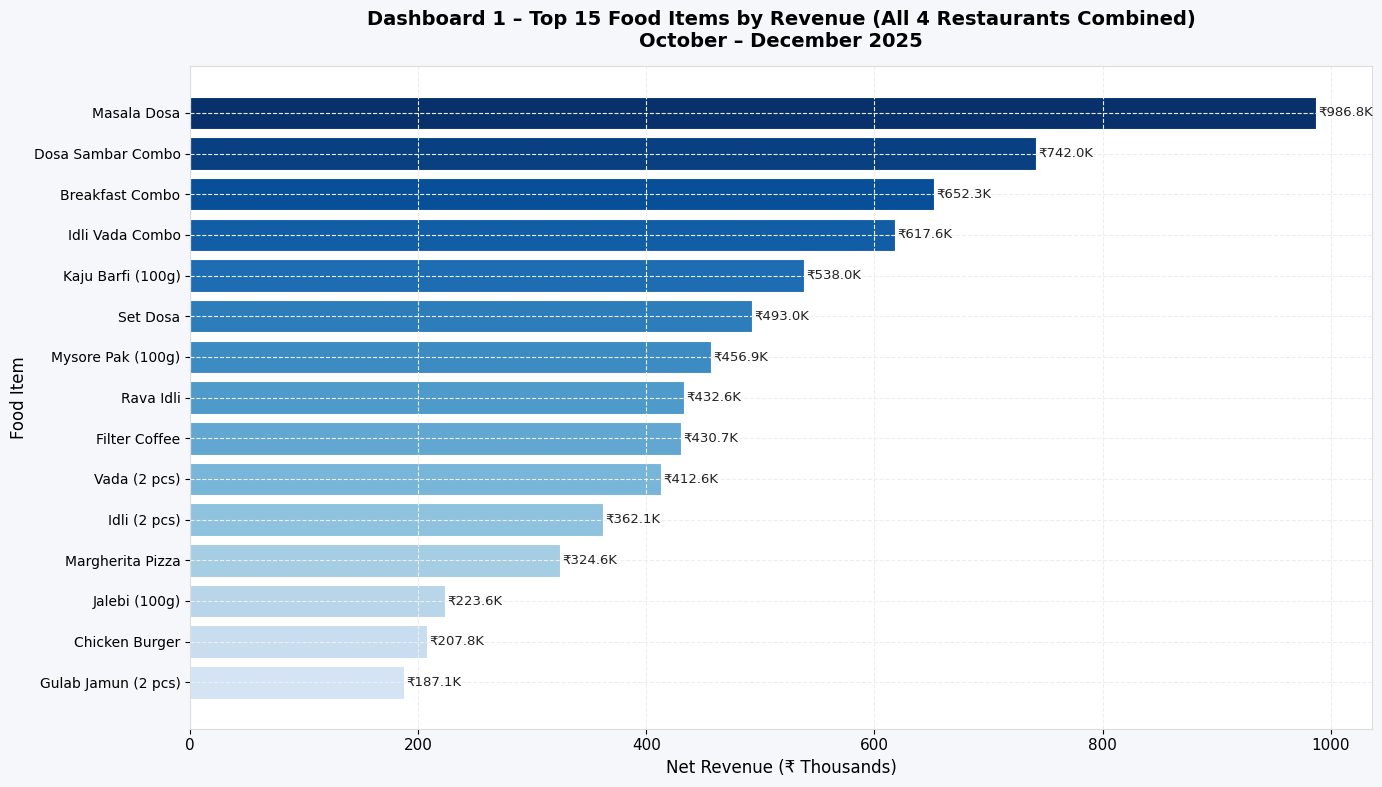

D1 Top-15 combined chart saved.


In [4]:
# ─── Top 15 food items by revenue – ALL restaurants combined ────────────
item_rev = (df.groupby('Food_Item')['Net_Sales']
              .sum()
              .sort_values(ascending=False)
              .head(15)
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#F5F7FA')
cmap = plt.cm.get_cmap('Blues', len(item_rev) + 3)
bar_colors = [cmap(i + 3) for i in range(len(item_rev))]
bars = ax.barh(item_rev.index, item_rev.values / 1000,
               color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, item_rev.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f'₹{val/1000:.1f}K', va='center', fontsize=9.5, color='#222')
ax.set_title(
    'Dashboard 1 – Top 15 Food Items by Revenue (All 4 Restaurants Combined)\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Net Revenue (₹ Thousands)', fontsize=12)
ax.set_ylabel('Food Item', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('d1_top15_items_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('D1 Top-15 combined chart saved.')

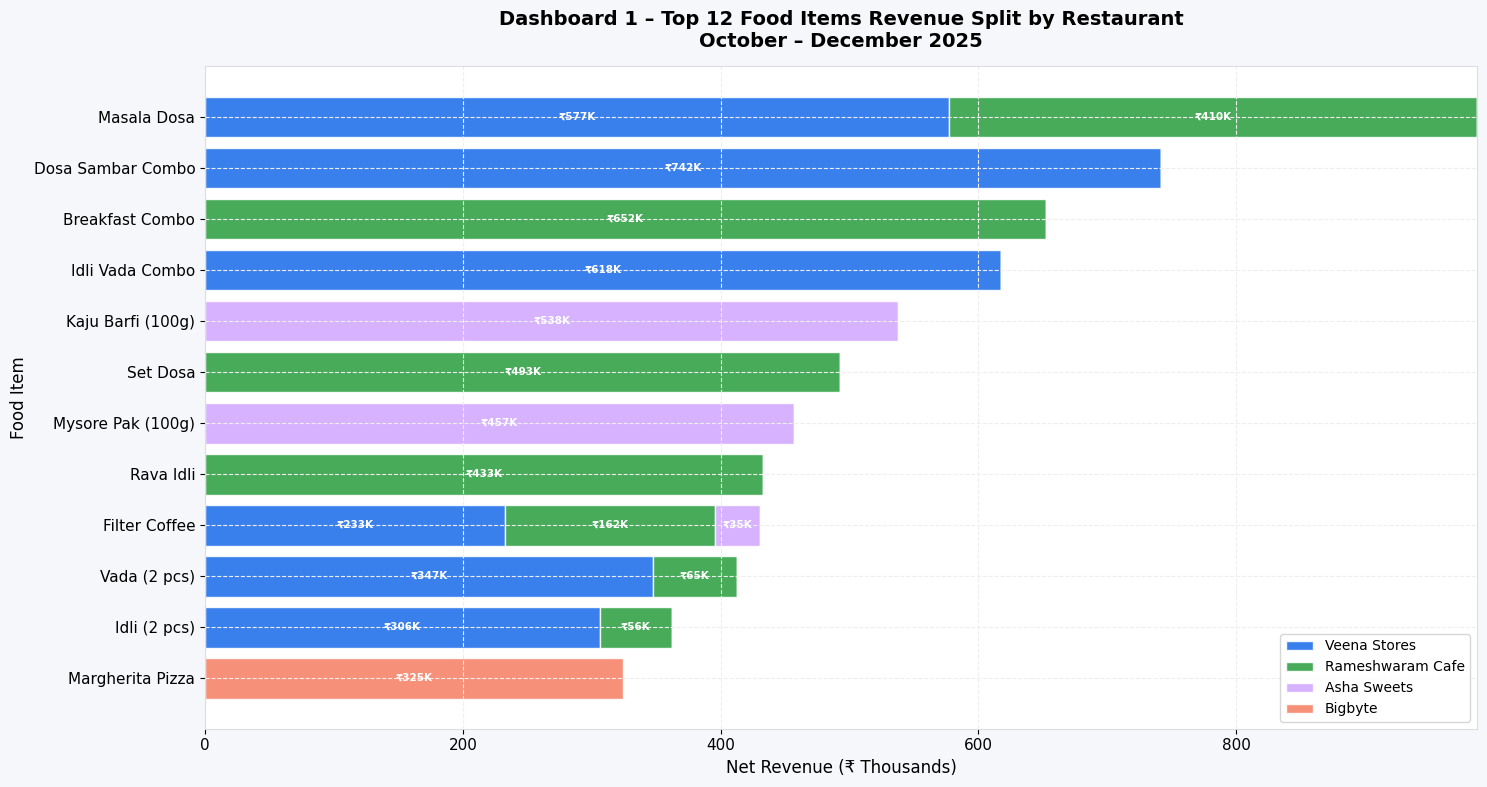

D1 stacked-by-restaurant chart saved.


In [5]:
# ─── Top 12 items stacked by restaurant ────────────────────────────────
top12_items = (df.groupby('Food_Item')['Net_Sales']
                 .sum()
                 .nlargest(12)
                 .index.tolist())
item_rest = (df[df['Food_Item'].isin(top12_items)]
               .groupby(['Food_Item','Restaurant'])['Net_Sales']
               .sum()
               .unstack('Restaurant')
               .reindex(columns=REST_ORDER)
               .fillna(0))
item_rest = item_rest.loc[item_rest.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('#F5F7FA')
left = np.zeros(len(item_rest))
for rest in REST_ORDER:
    if rest not in item_rest.columns: continue
    vals = item_rest[rest].values / 1000
    ax.barh(item_rest.index, vals, left=left,
            label=rest, color=REST_COLORS[rest], alpha=0.88, edgecolor='white')
    for i, (l, v) in enumerate(zip(left, vals)):
        if v > 15:
            ax.text(l + v/2, i, f'₹{v:.0f}K', ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color='white')
    left += vals
ax.set_title(
    'Dashboard 1 – Top 12 Food Items Revenue Split by Restaurant\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Net Revenue (₹ Thousands)', fontsize=12)
ax.set_ylabel('Food Item', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('d1_items_by_restaurant.png', dpi=150, bbox_inches='tight')
plt.show()
print('D1 stacked-by-restaurant chart saved.')

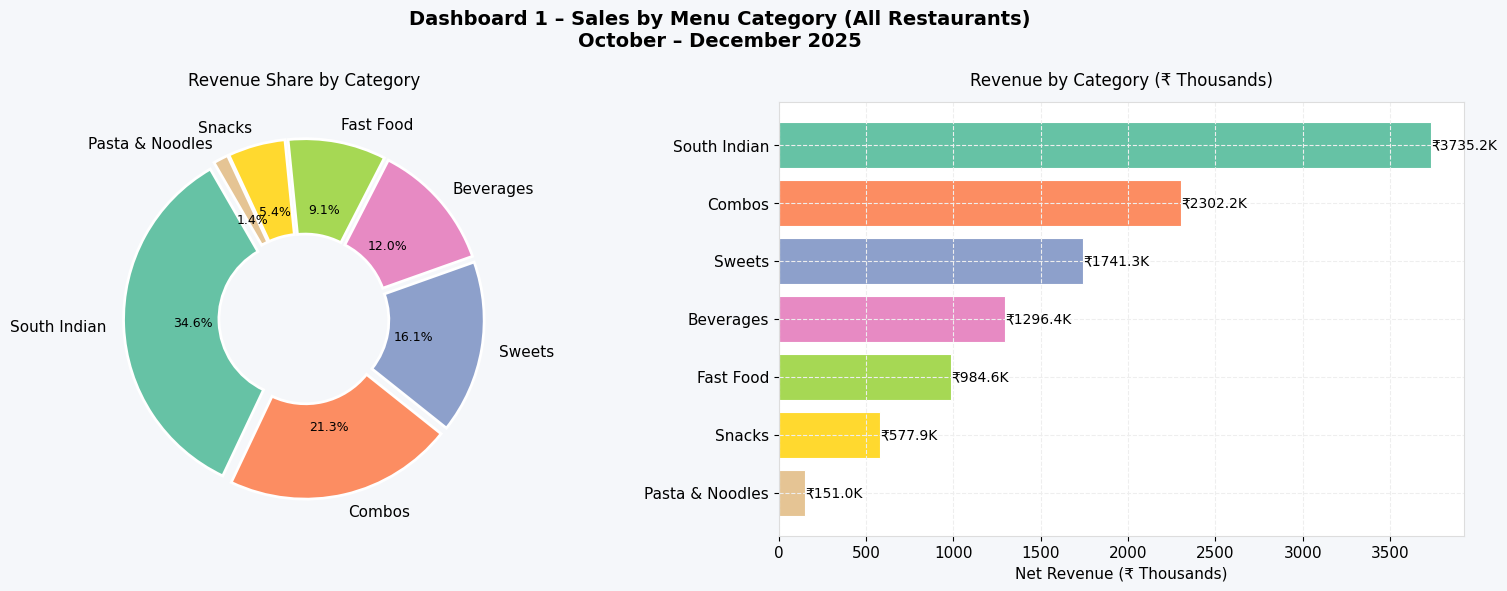

D1 category revenue chart saved.


In [6]:
# ─── Category revenue – all restaurants ────────────────────────────────
cat_rev = df.groupby('Category')['Net_Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Dashboard 1 – Sales by Menu Category (All Restaurants)\n'
    'October – December 2025',
    fontsize=14, fontweight='bold'
)
fig.patch.set_facecolor('#F5F7FA')

# Pie/donut
ax = axes[0]
palette = sns.color_palette('Set2', len(cat_rev))
wedges, texts, autos = ax.pie(
    cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
    startangle=120, colors=palette,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    explode=[0.04]*len(cat_rev)
)
for a in autos: a.set_fontsize(9)
ax.set_title('Revenue Share by Category', fontsize=12, pad=12)

# Horizontal bar
ax2 = axes[1]
bars = ax2.barh(cat_rev.index[::-1], cat_rev.values[::-1]/1000,
                color=palette[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, cat_rev.values[::-1]):
    ax2.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
             f'₹{val/1000:.1f}K', va='center', fontsize=10)
ax2.set_xlabel('Net Revenue (₹ Thousands)', fontsize=11)
ax2.set_title('Revenue by Category (₹ Thousands)', fontsize=12, pad=12)

plt.tight_layout()
plt.savefig('d1_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('D1 category revenue chart saved.')

In [7]:
# ─── Print top-5 items per restaurant (Dashboard 1 data table) ──────────
print('\n=== Dashboard 1 – Top 5 Food Items per Restaurant (Net Sales) ===')
for rest in REST_ORDER:
    top5 = (df[df['Restaurant']==rest]
              .groupby('Food_Item')[['Net_Sales','Quantity']]
              .sum()
              .sort_values('Net_Sales', ascending=False)
              .head(5))
    top5['Net_Sales'] = top5['Net_Sales'].map('₹{:,.0f}'.format)
    print(f'\n{rest}:')
    print(top5.to_string())


=== Dashboard 1 – Top 5 Food Items per Restaurant (Net Sales) ===

Veena Stores:
                  Net_Sales  Quantity
Food_Item                            
Dosa Sambar Combo  ₹741,950      7833
Idli Vada Combo    ₹617,632      7741
Masala Dosa        ₹576,851      7713
Vada (2 pcs)       ₹347,494      7741
Idli (2 pcs)       ₹306,364      7680

Rameshwaram Cafe:
                Net_Sales  Quantity
Food_Item                          
Breakfast Combo  ₹652,302      5450
Set Dosa         ₹492,988      5494
Rava Idli        ₹432,648      5421
Masala Dosa      ₹409,980      5480
Filter Coffee    ₹162,273      5426

Asha Sweets:
                    Net_Sales  Quantity
Food_Item                              
Kaju Barfi (100g)    ₹538,008      4495
Mysore Pak (100g)    ₹456,930      4581
Jalebi (100g)        ₹223,580      4485
Gulab Jamun (2 pcs)  ₹187,072      4689
Samosa (2 pcs)       ₹135,628      4533

Bigbyte:
                 Net_Sales  Quantity
Food_Item                           
Mar

---
# 📈 Dashboard 2
## Sales Comparison of All 4 Clients
### October – December 2025

> Monthly and overall sales performance comparison across all 4 restaurants with KPIs.


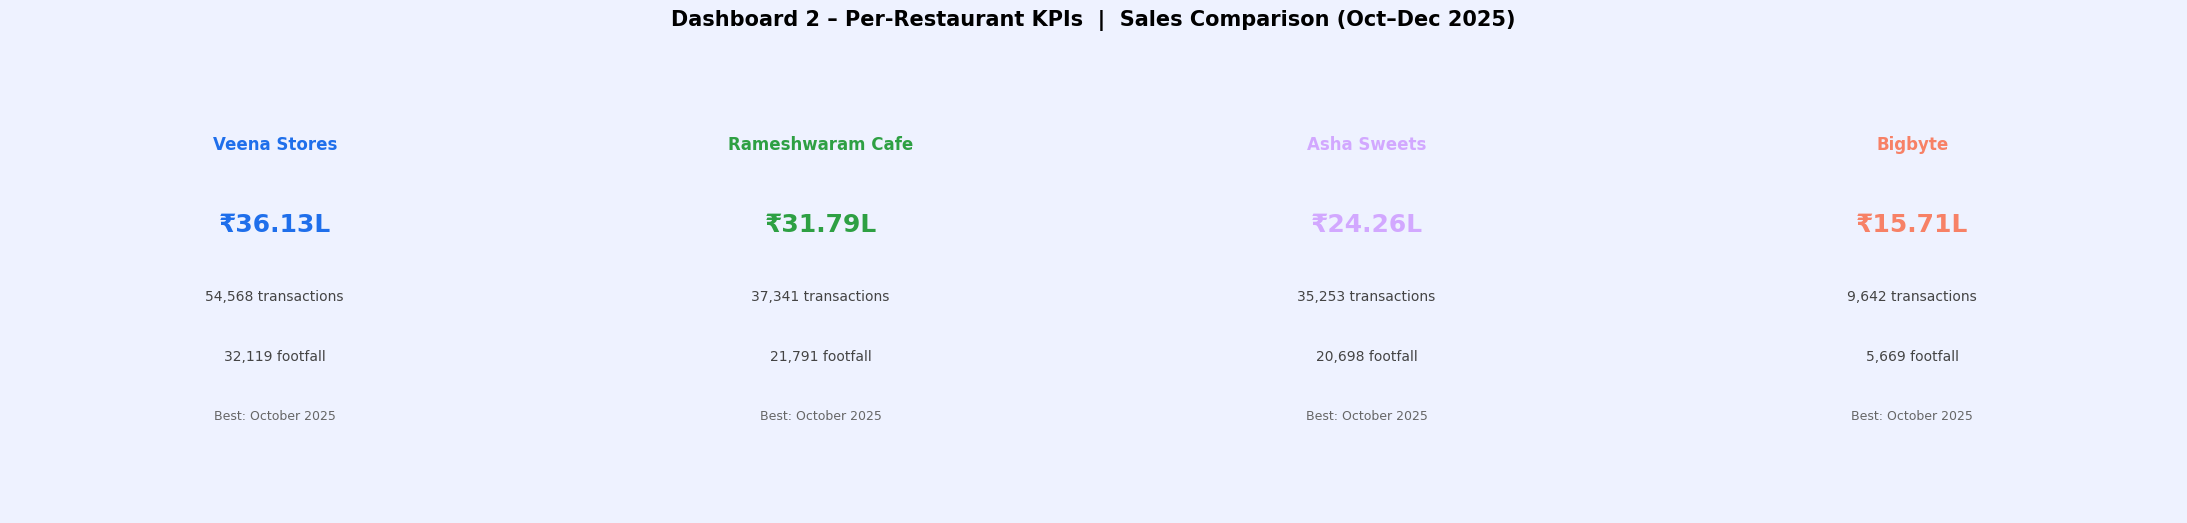

D2 KPI cards saved.


In [8]:
# ─── Per-restaurant KPIs ────────────────────────────────────────────────
rest_kpis = (df.groupby('Restaurant')
               .agg(
                   Revenue=('Net_Sales','sum'),
                   Transactions=('Transaction_ID','count'),
                   Footfall=('Customer_ID','nunique')
               )
               .reindex(REST_ORDER))
best_month = (df.groupby(['Restaurant','Month'])['Net_Sales']
                .sum()
                .groupby('Restaurant').idxmax()
                .map(lambda x: x[1]))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    'Dashboard 2 – Per-Restaurant KPIs  |  Sales Comparison (Oct–Dec 2025)',
    fontsize=15, fontweight='bold', y=1.04
)
fig.patch.set_facecolor('#EEF2FF')
for ax, rest in zip(axes, REST_ORDER):
    clr = REST_COLORS[rest]
    rev = rest_kpis.loc[rest,'Revenue']
    txn = rest_kpis.loc[rest,'Transactions']
    ff  = rest_kpis.loc[rest,'Footfall']
    bm  = best_month.get(rest,'-')
    ax.set_facecolor(clr + '18')
    ax.text(0.5, 0.88, rest,          ha='center', va='top', fontsize=12,
            fontweight='bold', color=clr, transform=ax.transAxes)
    ax.text(0.5, 0.70, f'₹{rev/1e5:.2f}L', ha='center', va='top', fontsize=18,
            fontweight='bold', color=clr, transform=ax.transAxes)
    ax.text(0.5, 0.52, f'{txn:,} transactions', ha='center', va='top', fontsize=10,
            color='#444', transform=ax.transAxes)
    ax.text(0.5, 0.38, f'{ff:,} footfall', ha='center', va='top', fontsize=10,
            color='#444', transform=ax.transAxes)
    ax.text(0.5, 0.24, f'Best: {bm}', ha='center', va='top', fontsize=9,
            color='#666', transform=ax.transAxes)
    ax.axis('off')
plt.tight_layout()
plt.savefig('d2_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('D2 KPI cards saved.')

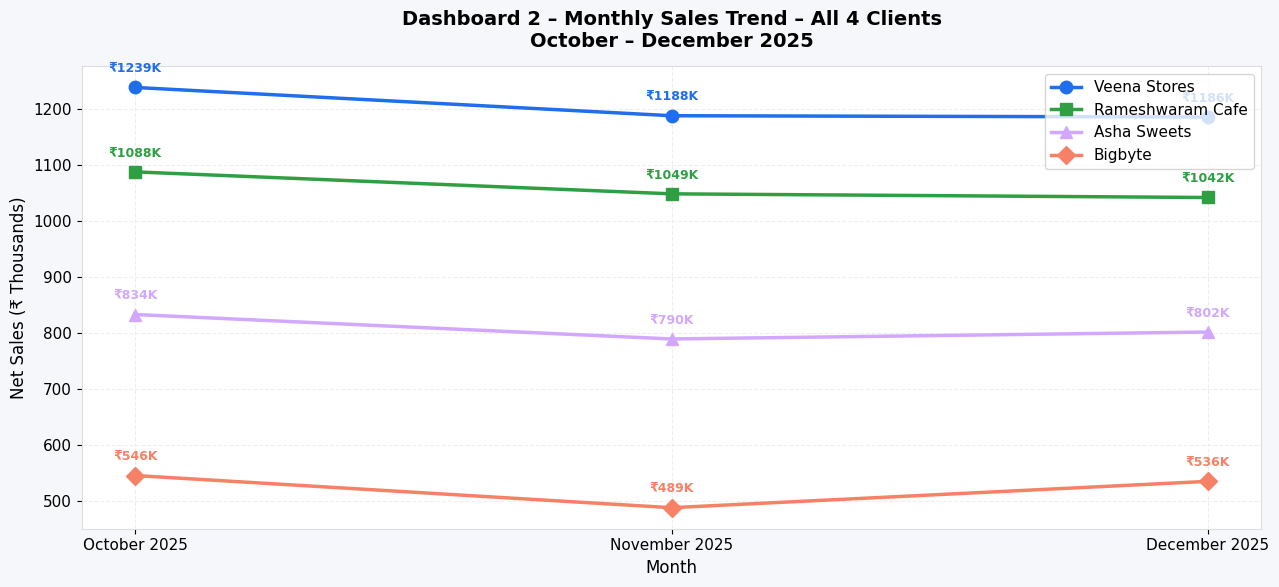

D2 monthly trend saved.


In [9]:
# ─── Monthly sales trend line ───────────────────────────────────────────
monthly = (df.groupby(['Month','Restaurant'])['Net_Sales']
             .sum().unstack('Restaurant')
             .reindex(columns=REST_ORDER) / 1000)
months_str = ['October 2025','November 2025','December 2025']

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F5F7FA')
markers = ['o','s','^','D']
for rest, mkr in zip(REST_ORDER, markers):
    ax.plot(months_str, monthly[rest].values,
            marker=mkr, linewidth=2.5, markersize=9,
            color=REST_COLORS[rest], label=rest)
    for xi, yv in enumerate(monthly[rest].values):
        ax.annotate(f'₹{yv:.0f}K', (xi, yv),
                    textcoords='offset points', xytext=(0,11),
                    ha='center', fontsize=9, color=REST_COLORS[rest],
                    fontweight='bold')
ax.set_title(
    'Dashboard 2 – Monthly Sales Trend – All 4 Clients\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Net Sales (₹ Thousands)', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.set_xticks(range(3))
ax.set_xticklabels(months_str, fontsize=11)
plt.tight_layout()
plt.savefig('d2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('D2 monthly trend saved.')

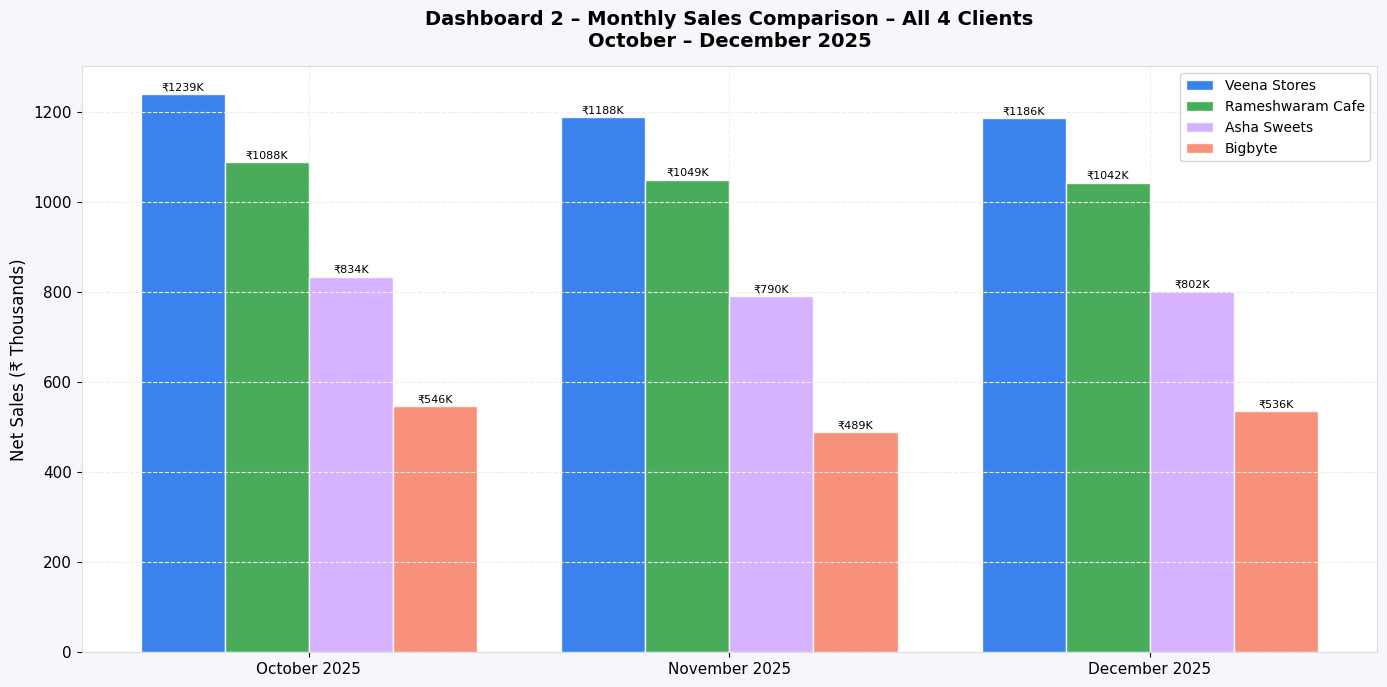

D2 grouped bar saved.


In [10]:
# ─── Grouped bar – monthly sales per restaurant ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F5F7FA')
x = np.arange(3)
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
for rest, off in zip(REST_ORDER, offsets):
    vals = monthly[rest].values
    bars = ax.bar(x + off*w, vals, width=w, label=rest,
                  color=REST_COLORS[rest], alpha=0.87, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                f'₹{bar.get_height():.0f}K',
                ha='center', va='bottom', fontsize=8)
ax.set_title(
    'Dashboard 2 – Monthly Sales Comparison – All 4 Clients\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xticks(x)
ax.set_xticklabels(months_str, fontsize=11)
ax.set_ylabel('Net Sales (₹ Thousands)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('d2_monthly_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('D2 grouped bar saved.')

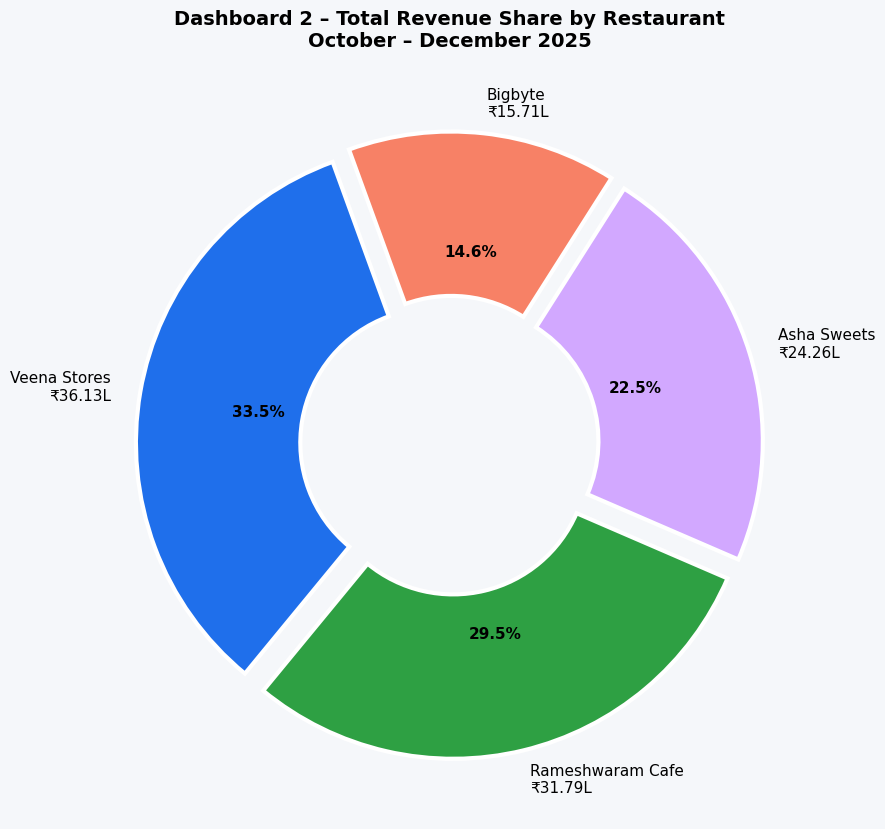

D2 sales share donut saved.


In [11]:
# ─── Total sales share donut ────────────────────────────────────────────
total_by_rest = df.groupby('Restaurant')['Net_Sales'].sum().reindex(REST_ORDER)

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('#F5F7FA')
wedges, texts, autos = ax.pie(
    total_by_rest.values,
    labels=[f'{r}\n₹{v/1e5:.2f}L' for r, v in total_by_rest.items()],
    autopct='%1.1f%%',
    startangle=110,
    colors=[REST_COLORS[r] for r in REST_ORDER],
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    explode=[0.05]*4
)
for t in texts:  t.set_fontsize(11)
for a in autos:  a.set_fontsize(11); a.set_fontweight('bold')
ax.set_title(
    'Dashboard 2 – Total Revenue Share by Restaurant\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=18
)
plt.tight_layout()
plt.savefig('d2_sales_share_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print('D2 sales share donut saved.')

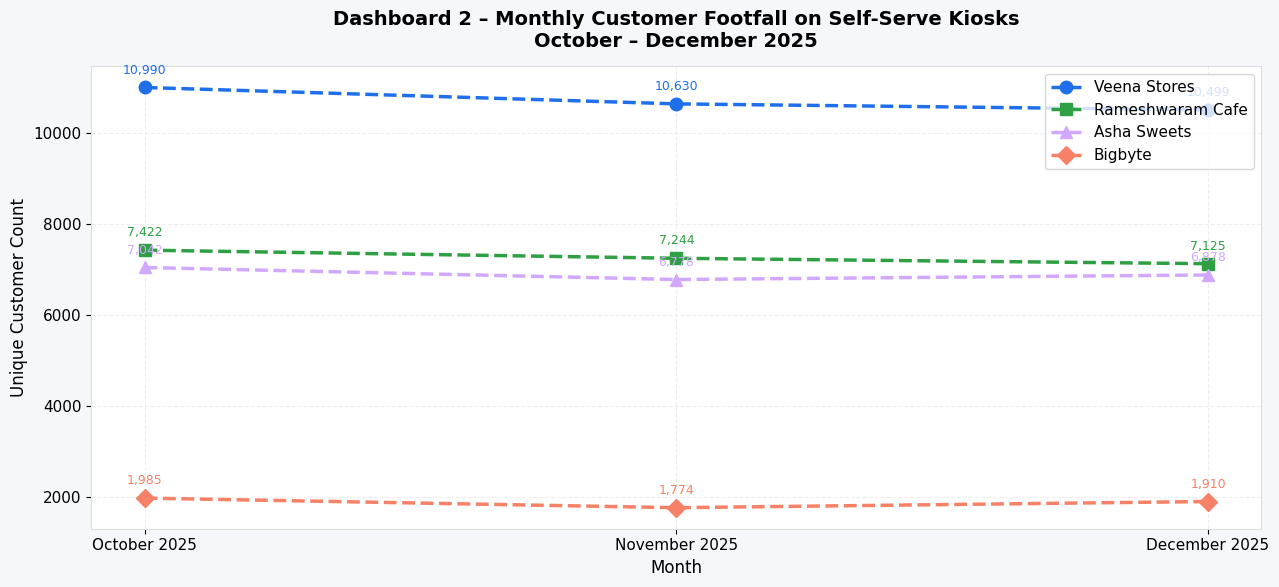

D2 footfall trend saved.


In [12]:
# ─── Customer footfall per restaurant per month ─────────────────────────
footfall = (df.groupby(['Month','Restaurant'])['Customer_ID']
              .nunique()
              .unstack('Restaurant')
              .reindex(columns=REST_ORDER))

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#F5F7FA')
for rest, mkr in zip(REST_ORDER, markers):
    ax.plot(months_str, footfall[rest].values,
            marker=mkr, linewidth=2.5, markersize=9,
            color=REST_COLORS[rest], label=rest, linestyle='--')
    for xi, yv in enumerate(footfall[rest].values):
        ax.annotate(f'{yv:,}', (xi, yv),
                    textcoords='offset points', xytext=(0,10),
                    ha='center', fontsize=9, color=REST_COLORS[rest])
ax.set_title(
    'Dashboard 2 – Monthly Customer Footfall on Self-Serve Kiosks\n'
    'October – December 2025',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Unique Customer Count', fontsize=12)
ax.legend(fontsize=11)
ax.set_xticks(range(3))
ax.set_xticklabels(months_str, fontsize=11)
plt.tight_layout()
plt.savefig('d2_footfall_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('D2 footfall trend saved.')

In [13]:
# ─── Summary table ──────────────────────────────────────────────────────
summary = rest_kpis.copy()
summary['Revenue (₹)'] = summary['Revenue'].map('₹{:,.0f}'.format)
summary['Rank'] = range(1, 5)
print('\n=== Dashboard 2 – Company Sales Summary (Oct–Dec 2025) ===')
print(summary[['Rank','Revenue (₹)','Transactions','Footfall']].to_string())
print(f'\nTotal Company Revenue: ₹{total_revenue:,.0f}  (₹{total_revenue/1e5:.2f}L)')


=== Dashboard 2 – Company Sales Summary (Oct–Dec 2025) ===
                  Rank Revenue (₹)  Transactions  Footfall
Restaurant                                                
Veena Stores         1  ₹3,612,578         54568     32119
Rameshwaram Cafe     2  ₹3,179,052         37341     21791
Asha Sweets          3  ₹2,425,734         35253     20698
Bigbyte              4  ₹1,571,108          9642      5669

Total Company Revenue: ₹10,788,471  (₹107.88L)


---
## Power BI Import Guide

### Steps
1. Open **Power BI Desktop** → **Get Data → Text/CSV** → select `Kiosks_Sales_PowerBI_Ready.csv`
2. Set `Date` → **Date**; `Order_DateTime` → **Date/Time**
3. Sort `Month` column by `Month_Num`
4. Add a slicer on **Month** for Oct / Nov / Dec filtering

### Dashboard 1 – Kiosk Sales Analytics: Food Item Revenue (All Clients)
| Visual | X-Axis / Field | Values | Filter/Legend |
|--------|---------------|--------|---------------|
| KPI Cards (6) | — | Total Revenue, Transactions, Footfall, Items Sold, Best Item, Top Restaurant | — |
| Horizontal Bar | Food_Item | Sum of Net_Sales | Top N = 15 |
| 100% Stacked Bar | Food_Item | Net_Sales | Legend = Restaurant |
| Donut + Bar | Category | Net_Sales | — |
| Slicer | Month | — | Oct / Nov / Dec |

### Dashboard 2 – Sales Comparison of All 4 Clients
| Visual | X-Axis / Field | Values | Legend |
|--------|---------------|--------|--------|
| KPI Cards (4) | — | Revenue, Transactions, Footfall, Best Month | per restaurant |
| Line Chart | Month | Net_Sales | Restaurant |
| Grouped Bar | Month | Net_Sales | Restaurant |
| Donut Chart | Restaurant | Net_Sales | — |
| Line Chart | Month | Count of Customer_ID | Restaurant |
